In [55]:
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import plotly.express as px

In [56]:
df = pd.read_csv(" jiji_housing_raw.csv")

In [57]:
df.head()

,title,region,region_name,region_parent_name,price,is_boost,property_size,bedrooms,bathrooms,furnishing
0,Furnished 3bdrm Bungalow in Ado-Odo/Ota for sale,"Ogun State, Ado-Odo/Ota",Ado-Odo/Ota,Ogun State,12000000.0,False,120.0,3.0,3.0,Furnished
1,"Furnished 2bdrm Block of Flats in Ajadi, Ologu...","Ibadan, Ologuneru",Ologuneru,Ibadan,80000000.0,False,600.0,2.0,2.0,Furnished
2,"7bdrm Duplex in Efab Metropolis, Karsana for sale","Gwagwa, Karsana",Karsana,Gwagwa,550000000.0,enterprise,850.0,7.0,8.0,Semi-Furnished
3,"3bdrm Block of Flats in Golin Estate, Kaura fo...","Abuja (FCT), Kaura",Kaura,Abuja (FCT),120000000.0,False,350.0,3.0,3.0,Unfurnished
4,4bdrm Duplex in Ikota Gra Estate for sale,"Lekki, Ikota",Ikota,Lekki,95000000.0,enterprise,300.0,4.0,4.0,Semi-Furnished


In [58]:
df.shape

(2000, 10)

In [59]:
df.isnull().sum()

title                  0
region                 0
region_name            0
region_parent_name     0
price                  0
is_boost               0
property_size         30
bedrooms               0
bathrooms              0
furnishing             0
dtype: int64

In [60]:
df = df.dropna()

In [61]:
df.isnull().sum()

title                 0
region                0
region_name           0
region_parent_name    0
price                 0
is_boost              0
property_size         0
bedrooms              0
bathrooms             0
furnishing            0
dtype: int64

In [62]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1970 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               1970 non-null   object 
 1   region              1970 non-null   object 
 2   region_name         1970 non-null   object 
 3   region_parent_name  1970 non-null   object 
 4   price               1970 non-null   float64
 5   is_boost            1970 non-null   object 
 6   property_size       1970 non-null   float64
 7   bedrooms            1970 non-null   float64
 8   bathrooms           1970 non-null   float64
 9   furnishing          1970 non-null   object 
dtypes: float64(4), object(6)
memory usage: 169.3+ KB


In [63]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)]
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1799 entries, 0 to 1998
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   title               1799 non-null   object 
 1   region              1799 non-null   object 
 2   region_name         1799 non-null   object 
 3   region_parent_name  1799 non-null   object 
 4   price               1799 non-null   float64
 5   is_boost            1799 non-null   object 
 6   property_size       1799 non-null   float64
 7   bedrooms            1799 non-null   float64
 8   bathrooms           1799 non-null   float64
 9   furnishing          1799 non-null   object 
dtypes: float64(4), object(6)
memory usage: 154.6+ KB


In [64]:
standard_cols = ['region', 'region_name', 'region_parent_name']
for col in standard_cols:
    df[col] = df[col].astype("string").str.strip().str.title()

In [65]:
df['region_parent_name'].nunique()
df['region_parent_name'].value_counts()

region_parent_name
Rivers State       516
Abuja (Fct)        293
Lagos State        232
Lekki              204
Ikeja               54
Ajah                50
Ipaja               40
Ikotun/Igando       36
Ogun State          26
Ikorodu             26
Magodo              23
Alimosho            22
Katampe             19
Amuwo-Odofin        18
Ibadan              16
Enugu State         16
Egbe/Idimu          16
Apo District        15
Ifako-Ijaiye        15
Osun State          14
Ojodu               14
Ibeju               12
Gwagwa               9
Surulere             9
Gwarinpa             9
Ogudu                9
Isolo                9
Oyo State            9
Port-Harcourt        7
Delta State          6
Kwara State          5
Agege                5
Shomolu              4
Kosofe               4
Ojo                  4
Ikoyi                3
Maryland             3
Badagry              3
Edo State            2
Gbagada              2
Wuse                 2
Jiwa                 2
Bwari          

In [66]:
state_variants = {
    'Lagos State': 'Lagos',
    'Abuja (Fct)': 'Abuja',
    'Rivers State': 'Rivers',
    'Ogun State': 'Ogun',
    'Enugu State': 'Enugu',
    'Osun State': 'Osun',
    'Delta State': 'Delta',
    'Kwara State': 'Kwara',
    'Edo State': 'Edo',
    'Plateau State': 'Plateau',
    'Nasarawa State': 'Nasarawa',
    'Anambra State': 'Anambra',
    'Ebonyi State': 'Ebonyi',
    'Imo State': 'Imo',
    'Oyo State': 'Oyo'
}

df['state_mapped'] = df['region_parent_name'].replace(state_variants)
neighborhood_to_state = {
    'Lekki': 'Lagos',
    'Ikeja': 'Lagos',
    'Ajah': 'Lagos',
    'Ipaja': 'Lagos',
    'Ikotun/Igando': 'Lagos',
    'Ikorodu': 'Lagos',
    'Magodo': 'Lagos',
    'Alimosho': 'Lagos',
    'Amuwo-Odofin': 'Lagos',
    'Egbe/Idimu': 'Lagos',
    'Ifako-Ijaiye': 'Lagos',
    'Ojodu': 'Lagos',
    'Ikoyi': 'Lagos',
    'Maryland': 'Lagos',
    'Yaba': 'Lagos',
    'Ojo': 'Lagos',
    'Shomolu': 'Lagos',
    'Agege': 'Lagos',
    'Kosofe': 'Lagos',
    'Badagry': 'Lagos',
    'Orile': 'Lagos',
    'Victoria Island': 'Lagos',
    'Gwarinpa': 'Abuja',
    'Lugbe District': 'Abuja',
    'Apo District': 'Abuja',
    'Katampe': 'Abuja',
    'Wuse': 'Abuja',
    'Jahi': 'Abuja',
    'Bwari': 'Abuja',
    'Gwagwa': 'Abuja',
    'Jiwa': 'Abuja',
    'Guzape District': 'Abuja',
    'Port-Harcourt': 'Rivers',
    'Sagamu': 'Ogun',
    'Enugu': 'Enugu',
    'Ibadan': 'Oyo',
    'Ejigbo': 'Lagos',
    'Ogba': 'Lagos',
    'Ibeju': 'Lagos'
}
df['state_mapped'] = df['state_mapped'].replace(neighborhood_to_state)
df['state_mapped'] = df['state_mapped'].fillna('Other')
df['state_mapped'].value_counts()

state_mapped
Lagos       795
Rivers      523
Abuja       351
Ogun         27
Oyo          25
Enugu        16
Osun         14
Isolo         9
Surulere      9
Ogudu         9
Delta         6
Kwara         5
Edo           2
Gbagada       2
Nasarawa      1
Plateau       1
Anambra       1
Ebonyi        1
Ojota         1
Imo           1
Name: count, dtype: Int64

In [67]:
average_house_price = df['price'].mean()
print(f"The average house price in Nigeria is ₦{average_house_price/1e6:.2f} million")

The average house price in Nigeria is ₦246.83 million


In [68]:
state_price = df.groupby('state_mapped')['price'].mean().sort_values(ascending=False)

highest_state = state_price.idxmax()
highest_price = state_price.max()

lowest_state = state_price.idxmin()
lowest_price = state_price.min()

print(f"The state with the highest mean property price is {highest_state} (₦{highest_price:,.2f})")
print(f"The state with the lowest mean property price is {lowest_state} (₦{lowest_price:,.2f})")

The state with the highest mean property price is Ogudu (₦451,111,111.11)
The state with the lowest mean property price is Kwara (₦21,960,000.00)


In [69]:
distribution = df['property_size'].describe()
distribution

count    1799.000000
mean      592.382435
std       473.061044
min        22.000000
25%       350.000000
50%       500.000000
75%       649.000000
max      5000.000000
Name: property_size, dtype: float64

In [70]:
bedroom_price = df.groupby('bedrooms')['price'].mean().reset_index()
bedroom_price.columns = ['Bedrooms', 'Average Price']

bedroom_price['Average Price'] = bedroom_price['Average Price'].apply(lambda x: f"₦{x:,.2f}")
bedroom_price

,Bedrooms,Average Price
0,1.0,"₦70,464,285.71"
1,2.0,"₦141,723,970.03"
2,3.0,"₦145,713,393.10"
3,4.0,"₦245,313,476.54"
4,5.0,"₦393,830,287.21"
5,6.0,"₦346,042,168.67"
6,7.0,"₦477,064,516.13"
7,8.0,"₦198,912,500.00"
8,9.0,"₦437,000,000.00"
9,10.0,"₦179,375,000.00"


In [71]:
bathroom_price = df.groupby('bathrooms')['price'].mean().reset_index()
bathroom_price.columns = ['Bathrooms', 'Average Price']

bathroom_price['Average Price'] = bathroom_price['Average Price'].apply(lambda x: f"₦{x:,.2f}")
bathroom_price

,Bathrooms,Average Price
0,1.0,"₦70,625,000.00"
1,2.0,"₦146,584,255.31"
2,3.0,"₦139,579,166.92"
3,4.0,"₦225,279,312.13"
4,5.0,"₦351,324,000.00"
5,6.0,"₦371,759,842.52"
6,7.0,"₦426,800,000.00"
7,8.0,"₦338,565,000.00"
8,9.0,"₦297,500,000.00"
9,10.0,"₦202,777,777.78"


In [72]:
feature_impact = pd.DataFrame({
    'Feature': ['Bedrooms', 'Bathrooms'],
    'Correlation_with_Price': [df['bedrooms'].corr(df['price']), df['bathrooms'].corr(df['price'])]
})
feature_impact

,Feature,Correlation_with_Price
0,Bedrooms,0.318146
1,Bathrooms,0.331319


In [73]:
region_listings = df['state_mapped'].value_counts().reset_index()
region_listings.columns = ['State', 'Number of Listings']
region_listings['Number of Listings'] = region_listings['Number of Listings'].astype(int)
region_listings.head(5)

,State,Number of Listings
0,Lagos,795
1,Rivers,523
2,Abuja,351
3,Ogun,27
4,Oyo,25


In [74]:
premium_df = df[df['is_boost'] == 'premium'] 

premium_regions = premium_df['state_mapped'].value_counts().reset_index()
premium_regions.columns = ['State', 'Number of Premium Listings']
premium_regions

,State,Number of Premium Listings
0,Lagos,12
1,Abuja,6
2,Oyo,3


In [75]:
furnishing_price = df.groupby('furnishing')['price'].mean().reset_index()
furnishing_price.columns = ['Furnishing', 'Average Price']
furnishing_price['Average Price'] = furnishing_price['Average Price'].apply(lambda x: f"₦{x:,.2f}")

furnishing_price

,Furnishing,Average Price
0,Furnished,"₦253,690,721.65"
1,Semi-Furnished,"₦255,866,037.73"
2,Unfurnished,"₦235,973,198.17"


In [76]:
listing_price = df.groupby('is_boost')['price'].mean().reset_index()
listing_price.columns = ['Listing Type', 'Average Price']
listing_price['Average Price'] = listing_price['Average Price'].apply(lambda x: f"₦{x:,.2f}")

listing_price

,Listing Type,Average Price
0,False,"₦265,878,947.37"
1,basic,"₦101,625,000.00"
2,diamond,"₦252,666,747.49"
3,enterprise,"₦244,729,698.38"
4,premium,"₦143,204,761.90"
5,vip,"₦237,156,923.08"
6,vip_gold,"₦100,000,000.00"


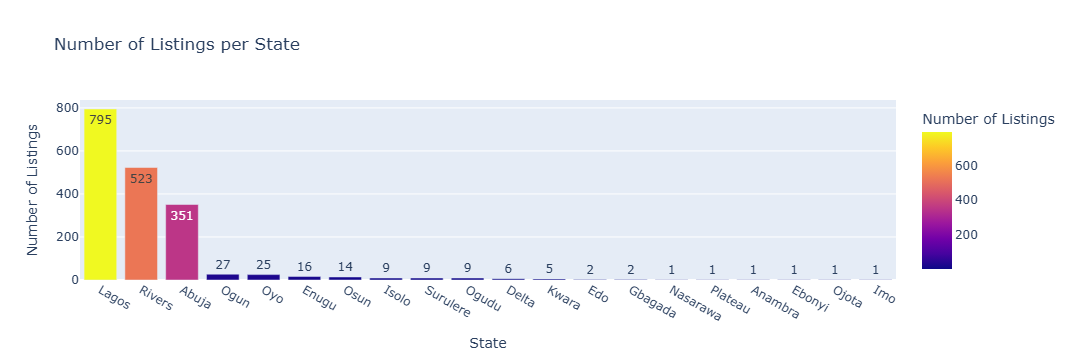

In [77]:
state_counts = df['state_mapped'].value_counts().reset_index()
state_counts.columns = ['State', 'Number of Listings']

fig1 = px.bar(state_counts, x='State', y='Number of Listings',
              title="Number of Listings per State",
              color='Number of Listings',
              text='Number of Listings')
fig1.show()

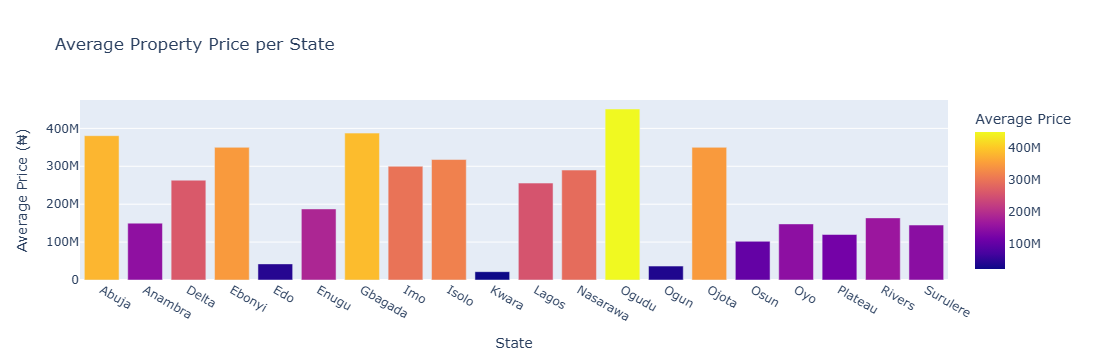

In [86]:
avg_price_state = df.groupby('state_mapped')['price'].mean().reset_index()
avg_price_state.columns = ['State', 'Average Price']
avg_price_state['Average Price Formatted'] = avg_price_state['Average Price'].apply(lambda x: f"₦{x:,.0f}")
fig = px.bar(avg_price_state, 
             x='State', 
             y='Average Price', 
             text='Average Price Formatted', 
             color='Average Price',          
             title="Average Property Price per State")
fig.update_traces(textposition='outside')
fig.update_layout(yaxis_title="Average Price (₦)",
                  xaxis_title="State",
                  uniformtext_minsize=8, uniformtext_mode='hide')

fig.show()

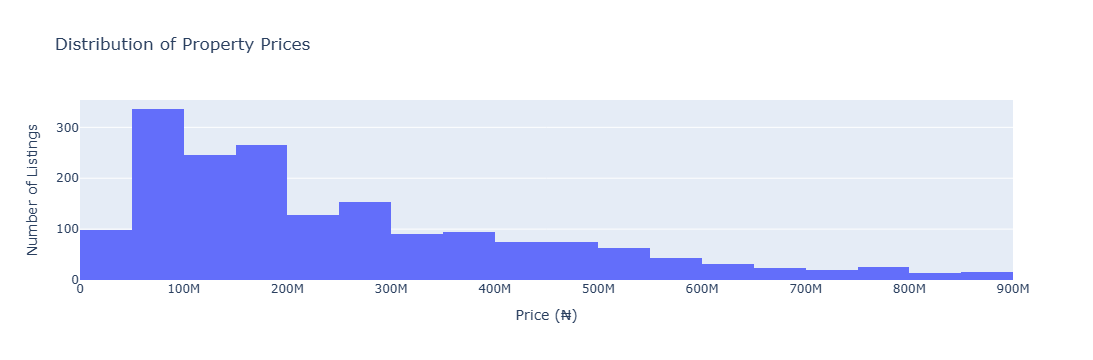

In [79]:
fig3 = px.histogram(df, x='price', nbins=30, title="Distribution of Property Prices")
fig3.update_layout(xaxis_title='Price (₦)', yaxis_title='Number of Listings')
fig3.show()

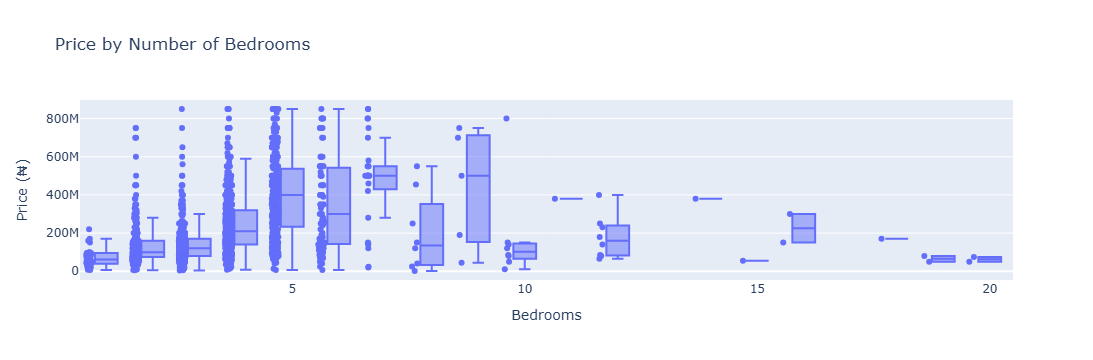

In [80]:
fig4 = px.box(df, x='bedrooms', y='price', title="Price by Number of Bedrooms",
              labels={'bedrooms':'Bedrooms', 'price':'Price (₦)'},
              points="all")  
fig4.show()

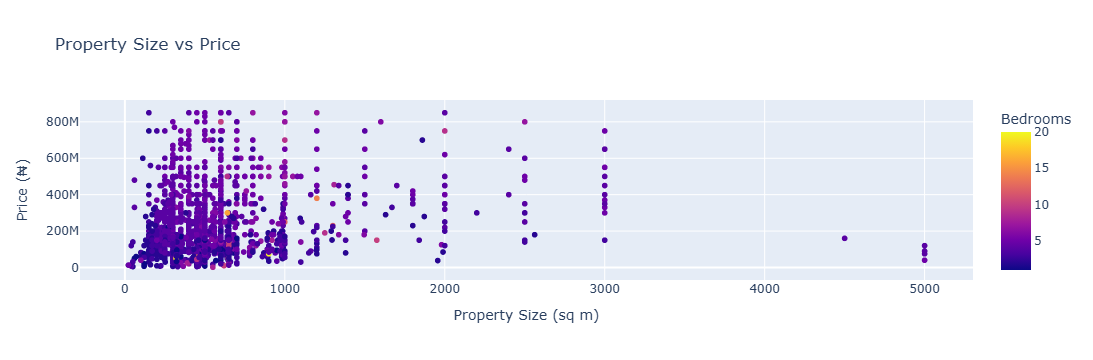

In [81]:
fig5 = px.scatter(df, x='property_size', y='price', color='bedrooms',
                  title="Property Size vs Price",
                  labels={'property_size':'Property Size (sq m)', 'price':'Price (₦)', 'bedrooms':'Bedrooms'},
                  hover_data=['state_mapped','furnishing'])
fig5.show()

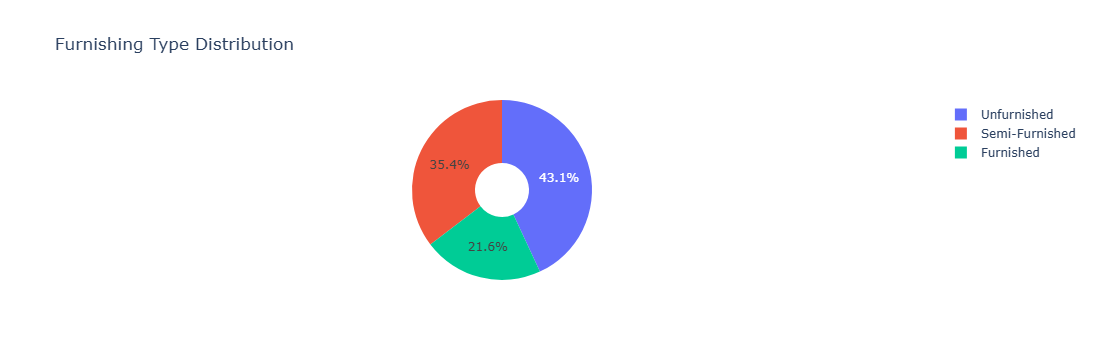

In [82]:
furnishing_counts = df['furnishing'].value_counts().reset_index()
furnishing_counts.columns = ['Furnishing', 'Count']

fig6 = px.pie(furnishing_counts, values='Count', names='Furnishing',
              title='Furnishing Type Distribution',
              hole=0.3) 
fig6.show()

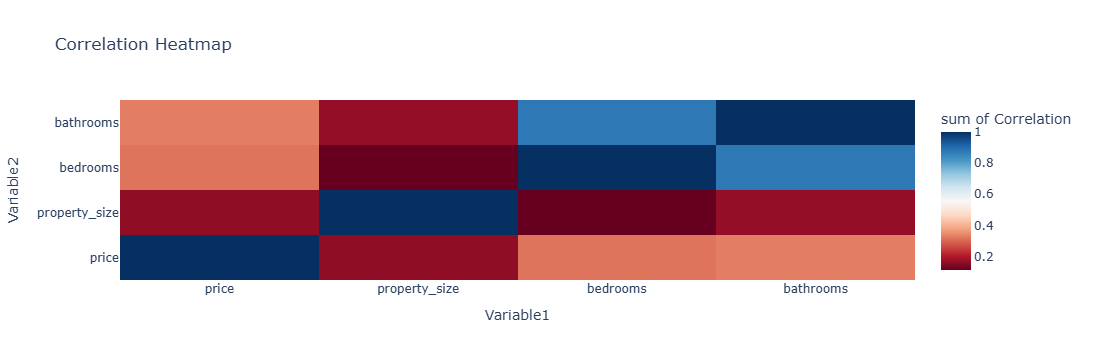

In [83]:
numeric_cols = ['price', 'property_size', 'bedrooms', 'bathrooms']
corr = df[numeric_cols].corr().reset_index().melt(id_vars='index')
corr.columns = ['Variable1','Variable2','Correlation']

fig7 = px.density_heatmap(corr, x='Variable1', y='Variable2', z='Correlation',
                          color_continuous_scale='RdBu', title="Correlation Heatmap")
fig7.show()

In [88]:
df.to_csv("jiji_housing_cleaned.csv", index=False)